In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [41]:
df = pd.read_csv("superstore_cleaned.csv")

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country_region,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,order_year,order_month,order_month_name,order_quarter,shipping_days,profit_margin_pct
0,1,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2020,11,November,4,3,16.00
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2020,11,November,4,3,30.00
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2020,6,June,2,4,47.00
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2019,10,October,4,7,-40.00
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2019,10,October,4,7,11.25


In [42]:
df.shape

(9994, 27)

In [43]:
total_sales = df["sales"].sum()

print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,297,200.86


In [44]:
total_profit = df["profit"].sum()

print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


In [45]:
total_orders = df["order_id"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 5,009


In [46]:
customer_count = df["customer_id"].nunique()

print(f"Customers: {customer_count:,}")

Customers: 793


In [47]:
aov = total_sales / total_orders

print(f"AOV: ${aov:,.2f}")

AOV: $458.61


In [48]:
profit_margin = (
    total_profit / total_sales
) * 100

print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 12.47%


In [49]:
monthly_sales = (
    df.groupby(["order_year","order_month"])
      ["sales"]
      .sum()
      .reset_index()
)

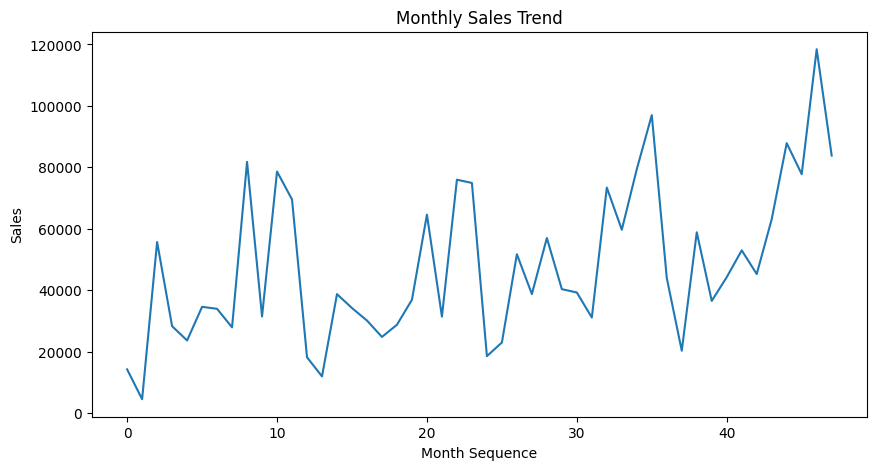

In [50]:
plt.figure(figsize=(10,5))

plt.plot(
    range(len(monthly_sales)),
    monthly_sales["sales"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month Sequence")
plt.ylabel("Sales")

plt.show()

In [51]:
plt.savefig(
    "monthly_sales_trend.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [52]:
monthly_profit = (
    df.groupby(["order_year","order_month"])
      ["profit"]
      .sum()
      .reset_index()
)

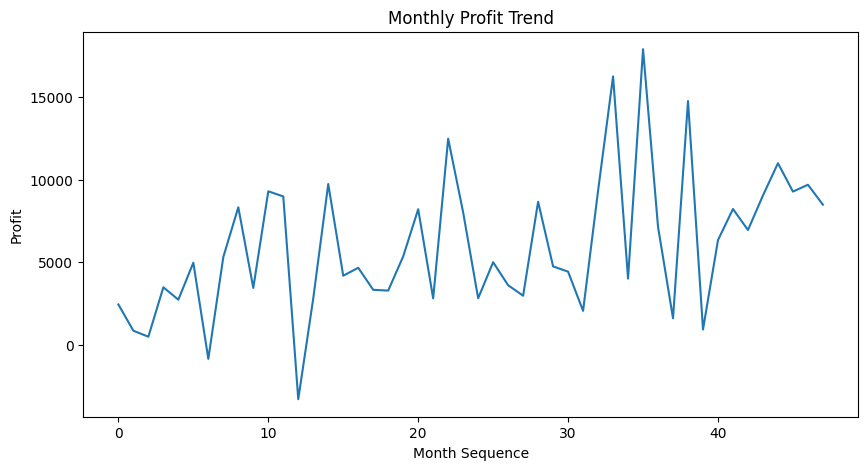

In [53]:
plt.figure(figsize=(10,5))

plt.plot(
    range(len(monthly_profit)),
    monthly_profit["profit"]
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month Sequence")
plt.ylabel("Profit")

plt.show()

In [54]:
plt.savefig(
    "monthly_profit_trend.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [55]:
category_sales = (
    df.groupby("category")
      ["sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

,sales
category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


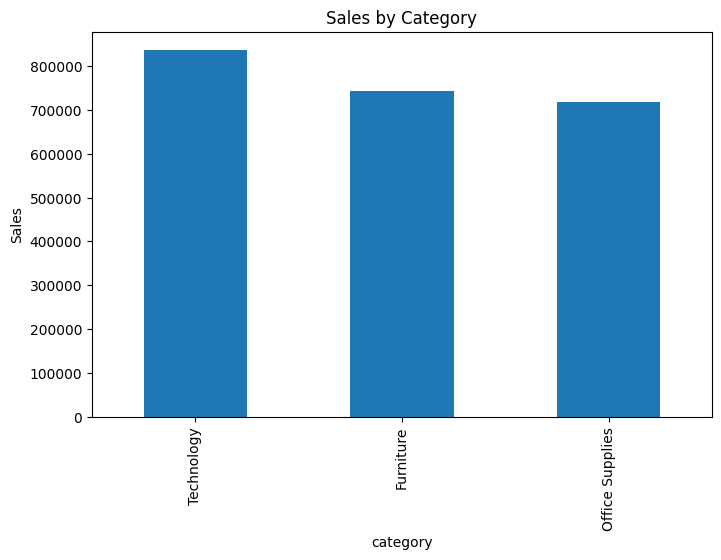

In [56]:
category_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.ylabel("Sales")

plt.show()

In [57]:
plt.savefig(
    "category_sales.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [58]:
category_profit = (
    df.groupby("category")
      ["profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

,profit
category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


In [59]:
region_sales = (
    df.groupby("region")
      ["sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales

,sales
region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


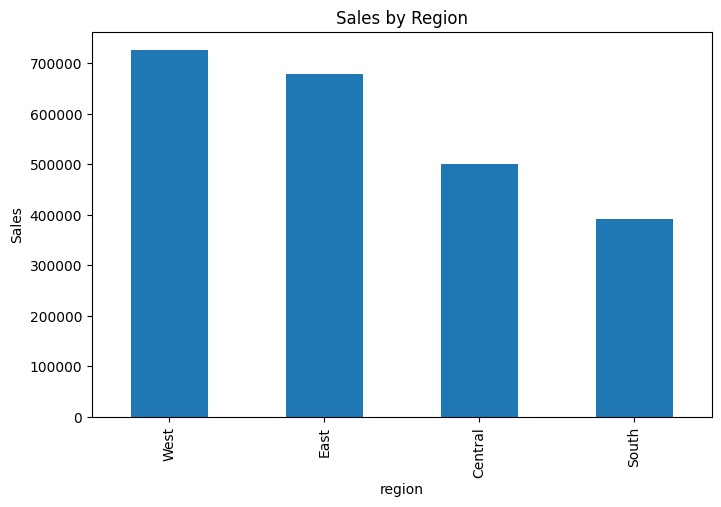

In [60]:
region_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Region")
plt.ylabel("Sales")

plt.show()

In [61]:
plt.savefig(
    "region_sales.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [62]:
top_products = (
    df.groupby("product_name")
      ["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

,sales
product_name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


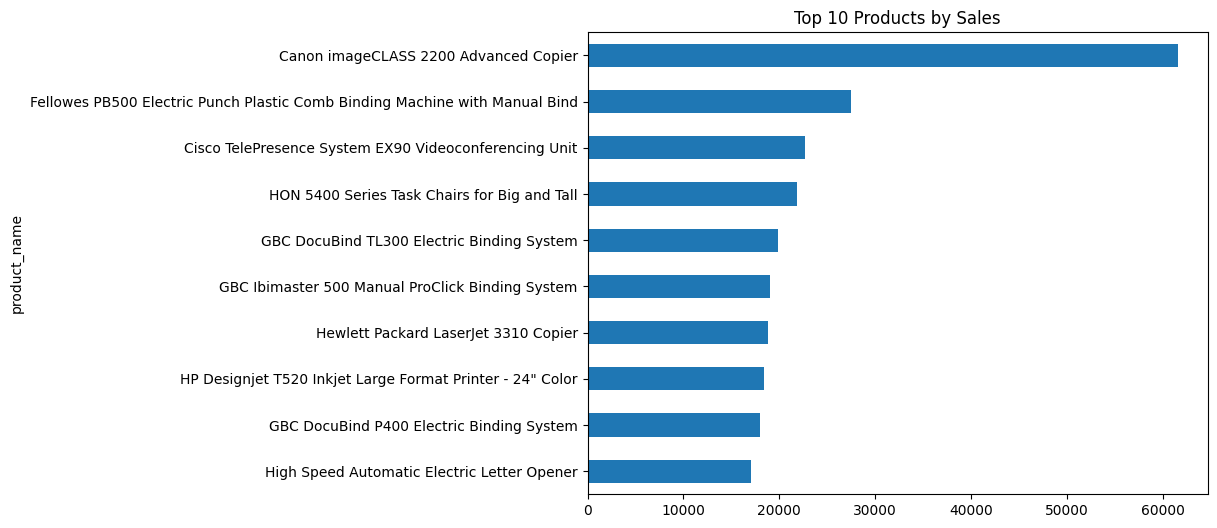

In [63]:
top_products.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 10 Products by Sales")

plt.show()

In [64]:
plt.savefig(
    "top_products.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [65]:
top_customers = (
    df.groupby("customer_name")
      ["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

,sales
customer_name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


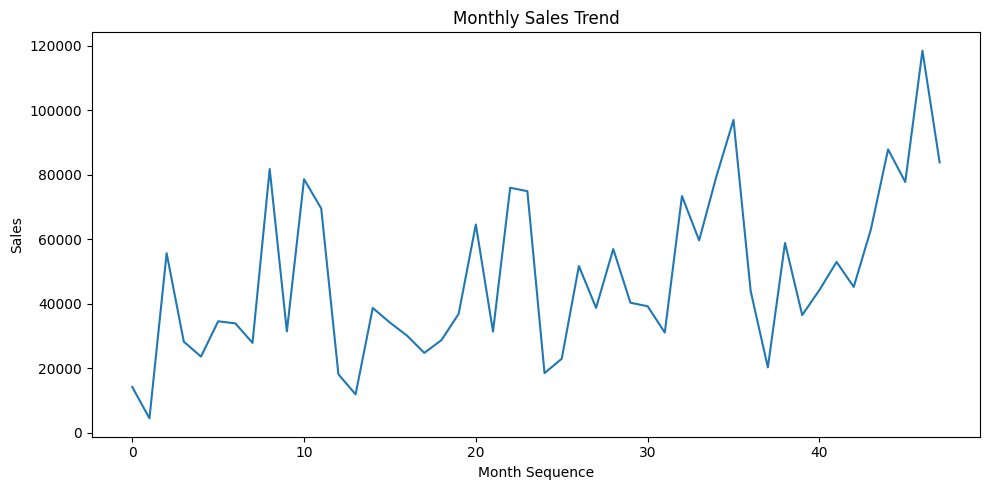

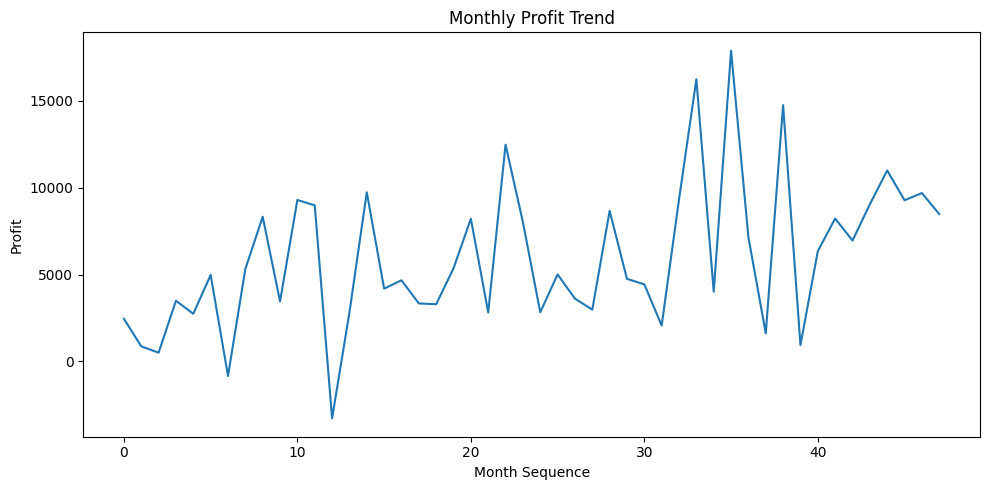

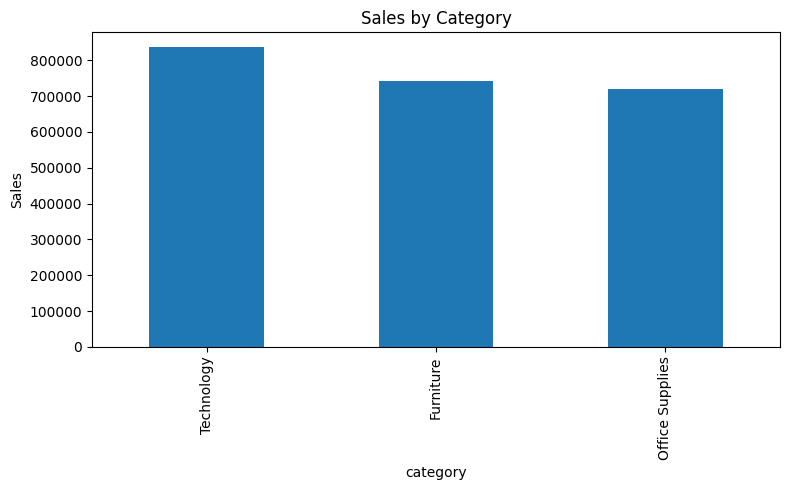

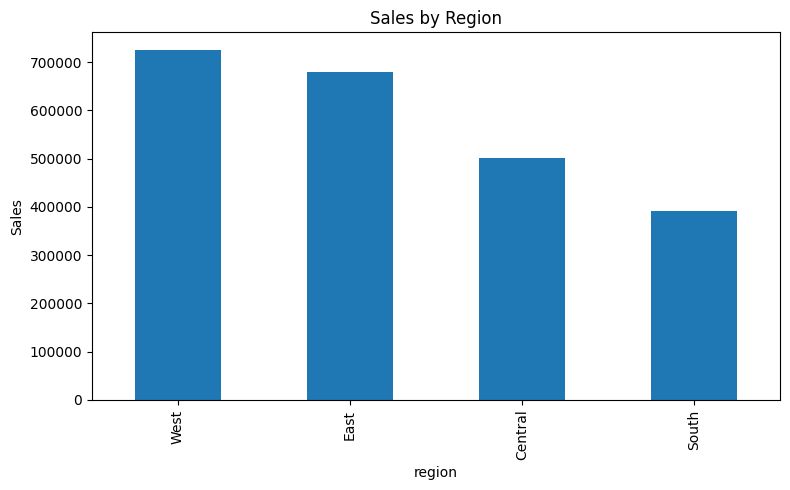

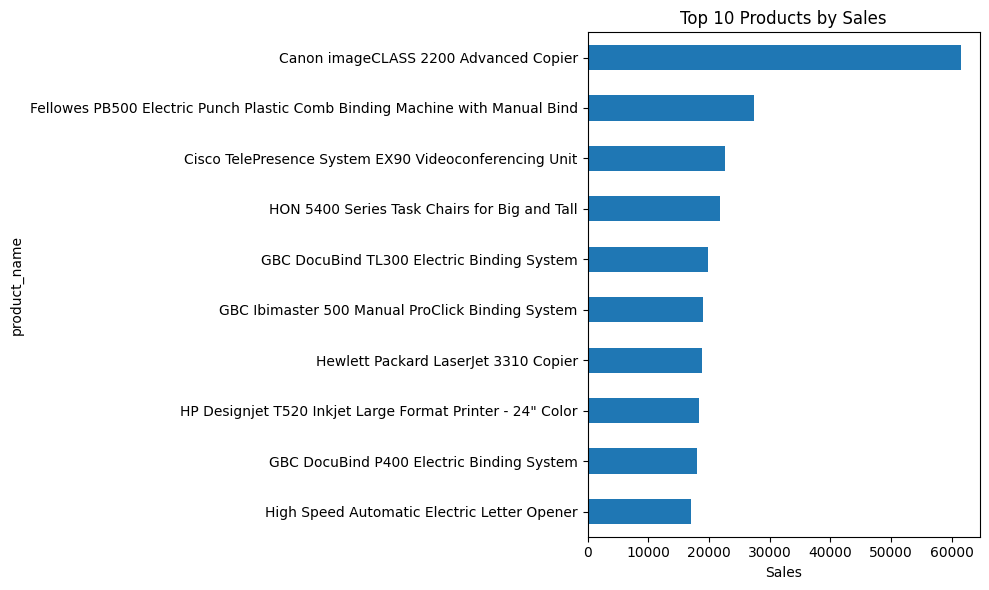

✅ All charts generated successfully!
Files created:
1. monthly_sales_trend.png
2. monthly_profit_trend.png
3. category_sales.png
4. region_sales.png
5. top_products.png


In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Monthly Sales Trend
# =========================

monthly_sales = (
    df.groupby(["order_year", "order_month"])["sales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(range(len(monthly_sales)), monthly_sales["sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Month Sequence")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# =========================
# 2. Monthly Profit Trend
# =========================

monthly_profit = (
    df.groupby(["order_year", "order_month"])["profit"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(range(len(monthly_profit)), monthly_profit["profit"])
plt.title("Monthly Profit Trend")
plt.xlabel("Month Sequence")
plt.ylabel("Profit")
plt.tight_layout()
plt.savefig("monthly_profit_trend.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# =========================
# 3. Category Sales
# =========================

category_sales = (
    df.groupby("category")["sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("category_sales.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# =========================
# 4. Region Sales
# =========================

region_sales = (
    df.groupby("region")["sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("region_sales.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# =========================
# 5. Top 10 Products
# =========================

top_products = (
    df.groupby("product_name")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.tight_layout()
plt.savefig("top_products.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("✅ All charts generated successfully!")
print("Files created:")
print("1. monthly_sales_trend.png")
print("2. monthly_profit_trend.png")
print("3. category_sales.png")
print("4. region_sales.png")
print("5. top_products.png")

In [67]:
# =========================
# EXECUTIVE KPIs
# =========================

total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()
customer_count = df["customer_id"].nunique()

aov = total_sales / total_orders

profit_margin = (total_profit / total_sales) * 100

print("===== EXECUTIVE KPIs =====")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Customer Count: {customer_count:,}")
print(f"Average Order Value (AOV): ${aov:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

# =========================
# TOP CATEGORY
# =========================

top_category = (
    df.groupby("category")["sales"]
      .sum()
      .sort_values(ascending=False)
)

print("\n===== TOP CATEGORY =====")
print(top_category.head(1))

# =========================
# TOP REGION
# =========================

top_region = (
    df.groupby("region")["sales"]
      .sum()
      .sort_values(ascending=False)
)

print("\n===== TOP REGION =====")
print(top_region.head(1))

# =========================
# TOP PRODUCT
# =========================

top_product = (
    df.groupby("product_name")["sales"]
      .sum()
      .sort_values(ascending=False)
)

print("\n===== TOP PRODUCT =====")
print(top_product.head(1))

# =========================
# TOP CUSTOMER
# =========================

top_customer = (
    df.groupby("customer_name")["sales"]
      .sum()
      .sort_values(ascending=False)
)

print("\n===== TOP CUSTOMER =====")
print(top_customer.head(1))

===== EXECUTIVE KPIs =====
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Customer Count: 793
Average Order Value (AOV): $458.61
Profit Margin: 12.47%

===== TOP CATEGORY =====
category
Technology    836154.033
Name: sales, dtype: float64

===== TOP REGION =====
region
West    725457.8245
Name: sales, dtype: float64

===== TOP PRODUCT =====
product_name
Canon imageCLASS 2200 Advanced Copier    61599.824
Name: sales, dtype: float64

===== TOP CUSTOMER =====
customer_name
Sean Miller    25043.05
Name: sales, dtype: float64


## Business Findings

### Executive Summary

- Total Sales: $2.30M
- Total Profit: $286K
- Profit Margin: 12.47%
- Total Orders: 5,009
- Customer Count: 793

### Key Insights

- Technology is the highest revenue-generating category.
- West region contributes the highest sales.
- Canon imageCLASS 2200 Advanced Copier is the top-selling product.
- Sean Miller is the highest-value customer.
- 18.72% of orders are loss-making and require investigation.
- Average shipping time is approximately 4 days.